In [ ]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels xgboost tensorflow

# Comparative Experimental Analysis of Forecasting Methods
## Member 5 — Tetuan City Power Consumption Dataset (TCPS)

**Course:** Applied Statistics and Experimental Analysis

**Dataset:** `data/power_consumption.csv`

**Target variable:** `Close`

**Features:** Open, High, Low, Close, Volume

This notebook implements the full experimental pipeline required by the project:

1. Descriptive Statistical Analysis
2. Time Series Analysis (Trend, Seasonality, Stationarity - ADF, ACF/PACF)
3. Data Preprocessing (Missing values, Scaling, Sliding Window w=30, 80/20 split, seed=42)
4. Train 5 forecasting models: Holt-Winters, ARIMA, XGBoost, LSTM, Transformer
5. Evaluation (MAE, RMSE, MAPE, R²)
6. Statistical Comparison (Paired t-test / Wilcoxon)
7. Visualization & Discussion

---
### ⚖️ A note on "fair" comparison across model families

Statistical models (Holt-Winters, ARIMA) and ML/DL models (XGBoost, LSTM, Transformer) consume
data differently. To make the comparison **fair and aligned**, this notebook uses the following design:

- The full series is split **chronologically** at `split_idx = floor(0.8 * N)` → **no shuffling**, **seed=42** wherever randomness applies (XGBoost, weight init).
- A **sliding window of `w = 30`** is used to build supervised samples for XGBoost / LSTM / Transformer:
  sample `t` uses history `[t-30, t)` to predict `y[t]`. Valid `t` starts at `30`.
- Holt-Winters and ARIMA are fit on the **training portion only**, then produce a **walk-forward
  one-step-ahead forecast** for every test timestamp `t` using the true history up to `t-1`
  (standard, leak-free procedure for these classical models).
- **Critically**, all 5 models are evaluated on the **exact same set of target timestamps**
  (`t = split_idx, ..., N-1`), so the per-point errors are directly paired — this is what allows
  a valid **paired t-test / Wilcoxon test** between models later in the notebook.
- Scaling (MinMaxScaler) is **fit on the training set only** and applied to ML/DL inputs to avoid
  data leakage. Holt-Winters/ARIMA operate on the original (unscaled) `Close` series, which is
  standard practice for these models and keeps their output directly interpretable in price units.


## 1. Setup & Imports

In [ ]:
# If running for the first time, uncomment to install dependencies
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels xgboost tensorflow

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

WINDOW = 30          # sliding window size (required by project spec)
TEST_RATIO = 0.20    # 80/20 split, no shuffling
DATA_PATH = "data/power_consumption.csv"

print("Setup complete. TensorFlow:", tf.__version__)


Setup complete. TensorFlow: 2.20.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset

Loading `data/power_consumption.csv`. The notebook auto-detects common Kaggle TCPS column naming
(`Date, Open, High, Low, Close, Adj Close, Volume`) and standardizes column names.

In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/TKUD_Proj/data/power_consumption.csv")
print(df_raw.shape)
df_raw.head()


(52416, 9)


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [5]:
# Make a copy of the raw data
df = df_raw.copy()

# 1. Parse the datetime column and set it as the index
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.rename(columns={"Datetime": "Date"}) # Rename it to Date so the rest of the TA's code doesn't break
df = df.sort_values("Date").reset_index(drop=True)
df = df.set_index("Date")

# 2. Define the features requested by the rubric, plus the target
FEATURES = ["Temperature", "Humidity", "WindSpeed", "DiffuseFlows", "PowerConsumption_Zone1"]
TARGET = "PowerConsumption_Zone1"

# 3. Filter the dataframe to only include our selected columns
df = df[FEATURES]

print(df.shape)
df.head()

(52416, 5)


,Temperature,Humidity,WindSpeed,DiffuseFlows,PowerConsumption_Zone1
Date,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.119,34055.69620
2017-01-01 00:10:00,6.414,74.5,0.083,0.085,29814.68354
2017-01-01 00:20:00,6.313,74.5,0.080,0.100,29128.10127
2017-01-01 00:30:00,6.121,75.0,0.083,0.096,28228.86076
2017-01-01 00:40:00,5.921,75.7,0.081,0.085,27335.69620


## 3. Descriptive Statistical Analysis (Step 1)

Required statistics: N, Mean, Median, Variance, Std, Min, Max, Skewness, Kurtosis.

In [6]:
desc_stats = pd.DataFrame({
    "N": df.count(),
    "Mean": df.mean(),
    "Median": df.median(),
    "Variance": df.var(),
    "Std": df.std(),
    "Min": df.min(),
    "Max": df.max(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurtosis()
})
desc_stats


,N,Mean,Median,Variance,Std,Min,Max,Skewness,Kurtosis
Temperature,52416,18.810024,18.78000,3.381976e+01,5.815476,3.2470,40.01000,0.196719,-0.303321
Humidity,52416,68.259518,69.86000,2.418391e+02,15.551177,11.3400,94.80000,-0.625166,-0.121860
WindSpeed,52416,1.959489,0.08600,5.517152e+00,2.348862,0.0500,6.48300,0.462423,-1.783169
DiffuseFlows,52416,75.028022,4.45600,1.542836e+04,124.210949,0.0110,936.00000,2.456907,7.002902
PowerConsumption_Zone1,52416,32344.970564,32265.92034,5.084492e+07,7130.562564,13895.6962,52204.39512,0.228864,-0.754054


In [7]:
print(f"Missing values per column:\n{df.isna().sum()}")
print(f"\nDate range: {df.index.min()} -> {df.index.max()}")
print(f"Total observations: {len(df)}")


Missing values per column:
Temperature               0
Humidity                  0
WindSpeed                 0
DiffuseFlows              0
PowerConsumption_Zone1    0
dtype: int64

Date range: 2017-01-01 00:00:00 -> 2017-12-30 23:50:00
Total observations: 52416


### 3.1 Histogram — Distribution Analysis

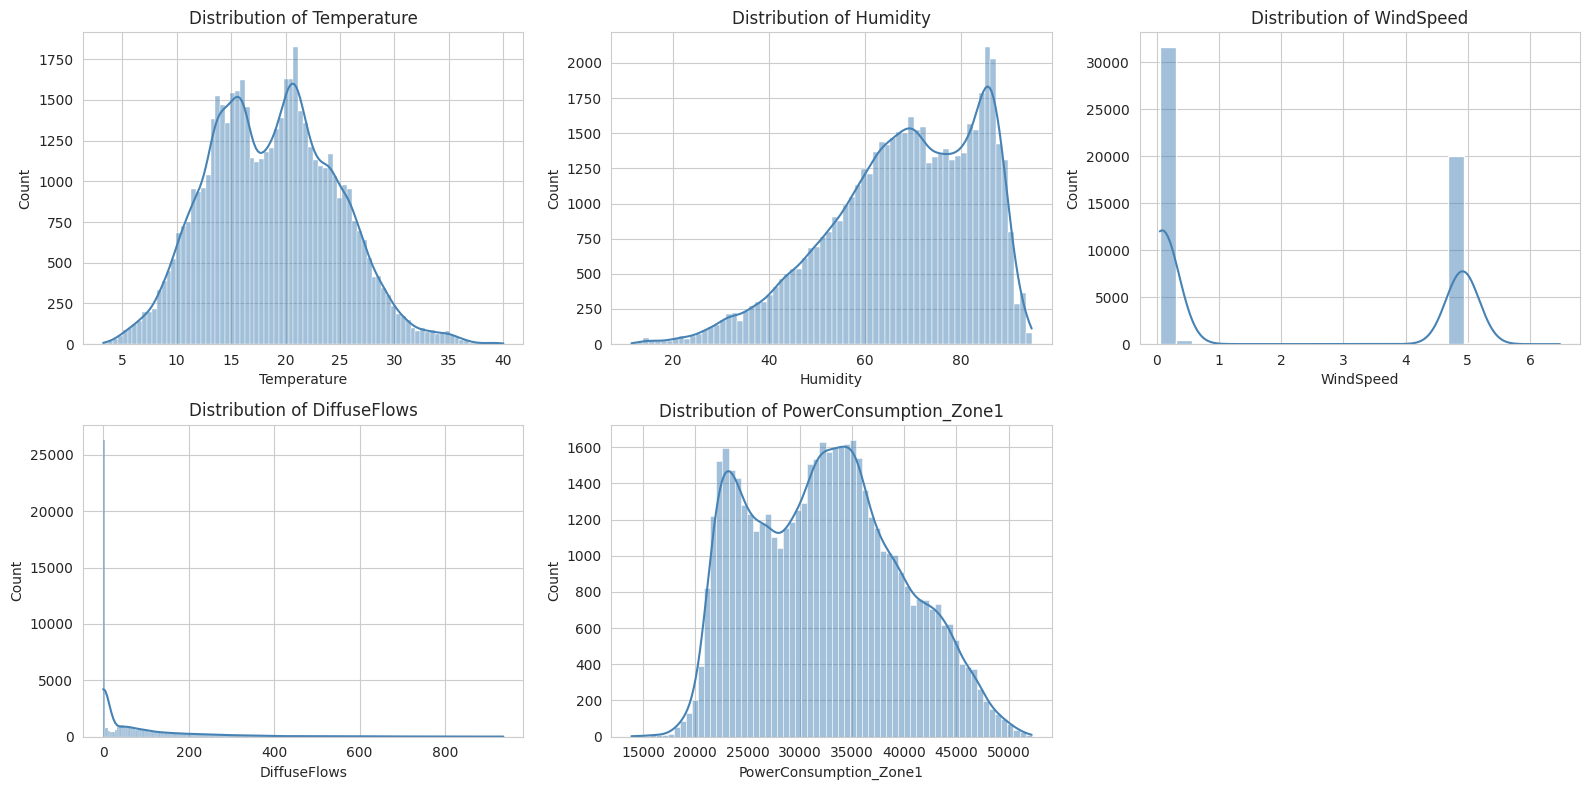

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
for ax in axes.flatten()[len(FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 3.2 Boxplot — Outlier Detection

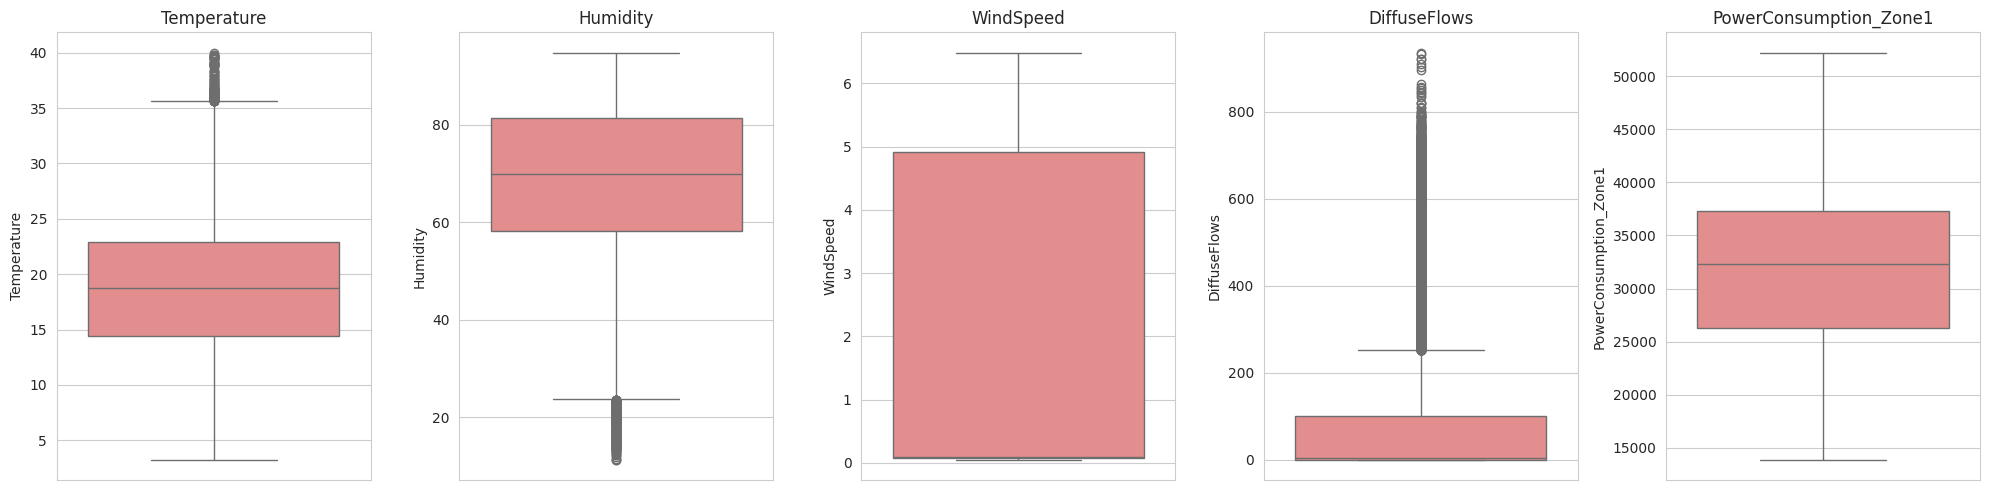

In [9]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(4*len(FEATURES), 5))
for ax, col in zip(axes, FEATURES):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 3.3 Time Series Plot — Trend & Seasonality (Close Price)

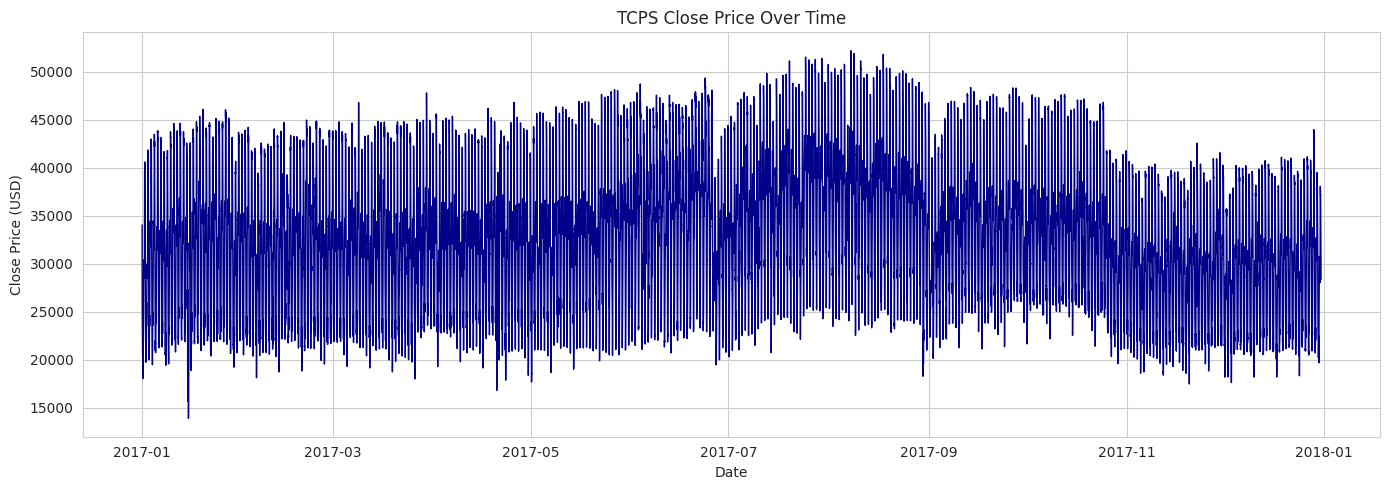

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df[TARGET], color="darkblue", linewidth=1)
plt.title("TCPS Close Price Over Time")
plt.xlabel("Date"); plt.ylabel("Close Price (USD)")
plt.tight_layout()
plt.show()

## 4. Time Series Analysis (Step 2)

### 4.1 Trend & Seasonal Decomposition
Financial daily data has no fixed calendar seasonality, but we run an additive decomposition
(period = 144 trading days ≈ 1 year) to visualize the underlying trend component.

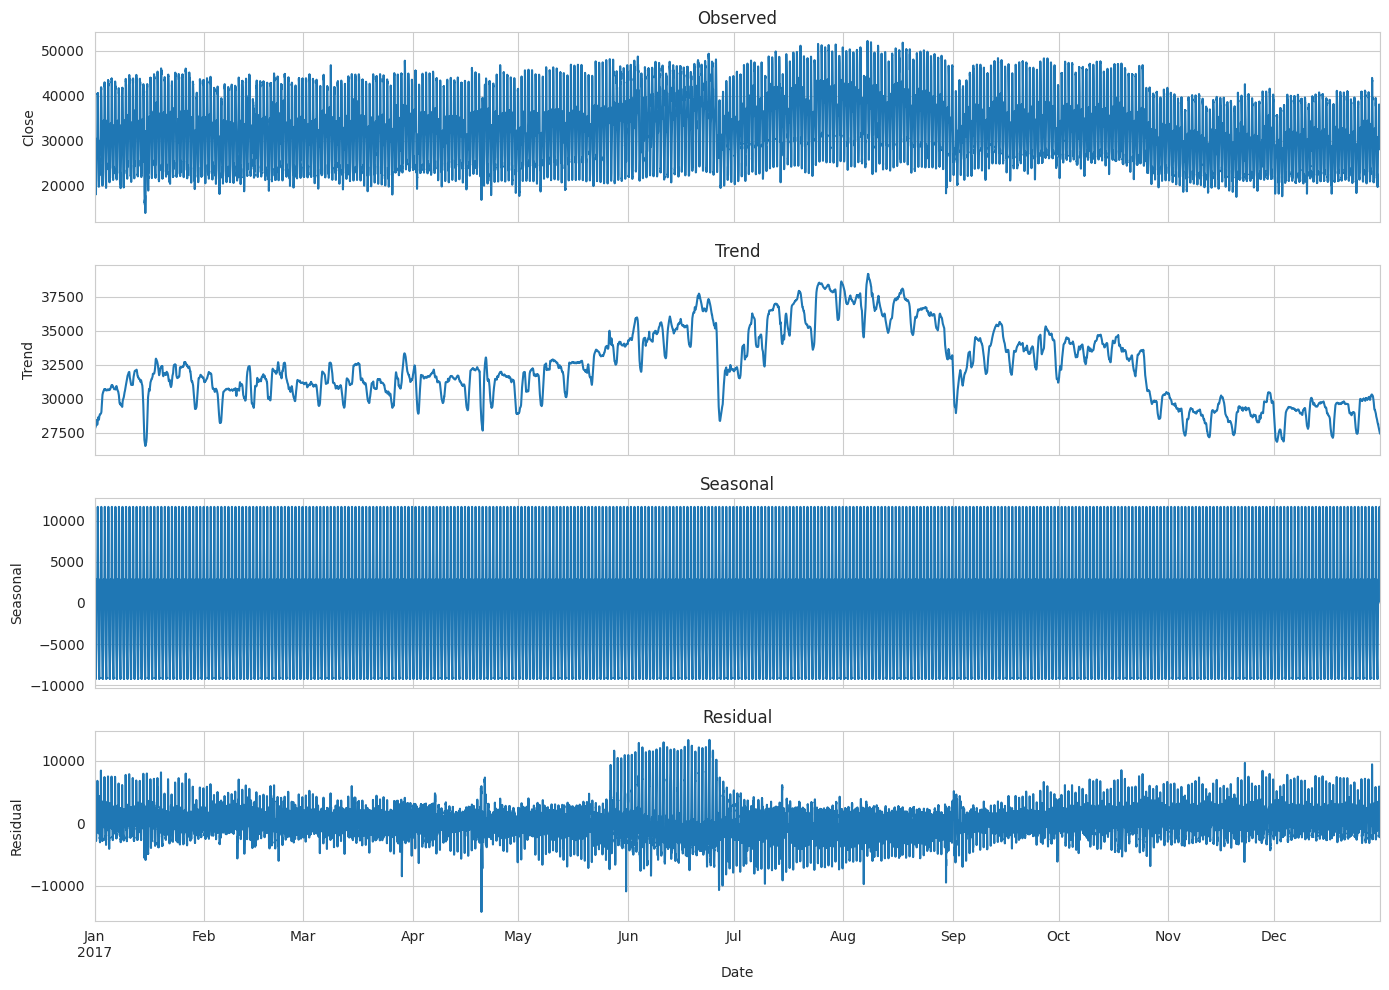

In [11]:
period = 144
decomposition = seasonal_decompose(df[TARGET], model="additive", period=period, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed"); axes[0].set_ylabel("Close")
decomposition.trend.plot(ax=axes[1], title="Trend"); axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal"); axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual"); axes[3].set_ylabel("Residual")
plt.tight_layout()
plt.show()


### 4.2 Stationarity Analysis — Augmented Dickey-Fuller (ADF) Test

**H₀:** The series is non-stationary (has a unit root)
**H₁:** The series is stationary

Stock price levels are typically **non-stationary** (random-walk-like), so we expect to
**fail to reject H₀** on raw `Close`. We also test the **first difference / log return**
for reference, which is commonly stationary.

In [12]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"Critical Value ({k}) : {v:.4f}")
    conclusion = "Stationary (reject H0)" if result[1] < 0.05 else "Non-stationary (fail to reject H0)"
    print(f"Conclusion    : {conclusion}\n")
    return result[1]

p_close = adf_report(df[TARGET], "Power (raw level)")
p_diff  = adf_report(df[TARGET].diff(), "Power (1st difference)")
p_logret = adf_report(np.log(df[TARGET]).diff(), "Log Return")

--- ADF Test: Power (raw level) ---
ADF Statistic : -32.1213
p-value       : 0.0000
Critical Value (1%) : -3.4305
Critical Value (5%) : -2.8616
Critical Value (10%) : -2.5668
Conclusion    : Stationary (reject H0)

--- ADF Test: Power (1st difference) ---
ADF Statistic : -40.1010
p-value       : 0.0000
Critical Value (1%) : -3.4305
Critical Value (5%) : -2.8616
Critical Value (10%) : -2.5668
Conclusion    : Stationary (reject H0)

--- ADF Test: Log Return ---
ADF Statistic : -40.1533
p-value       : 0.0000
Critical Value (1%) : -3.4305
Critical Value (5%) : -2.8616
Critical Value (10%) : -2.5668
Conclusion    : Stationary (reject H0)



### 4.3 Autocorrelation Analysis — ACF / PACF

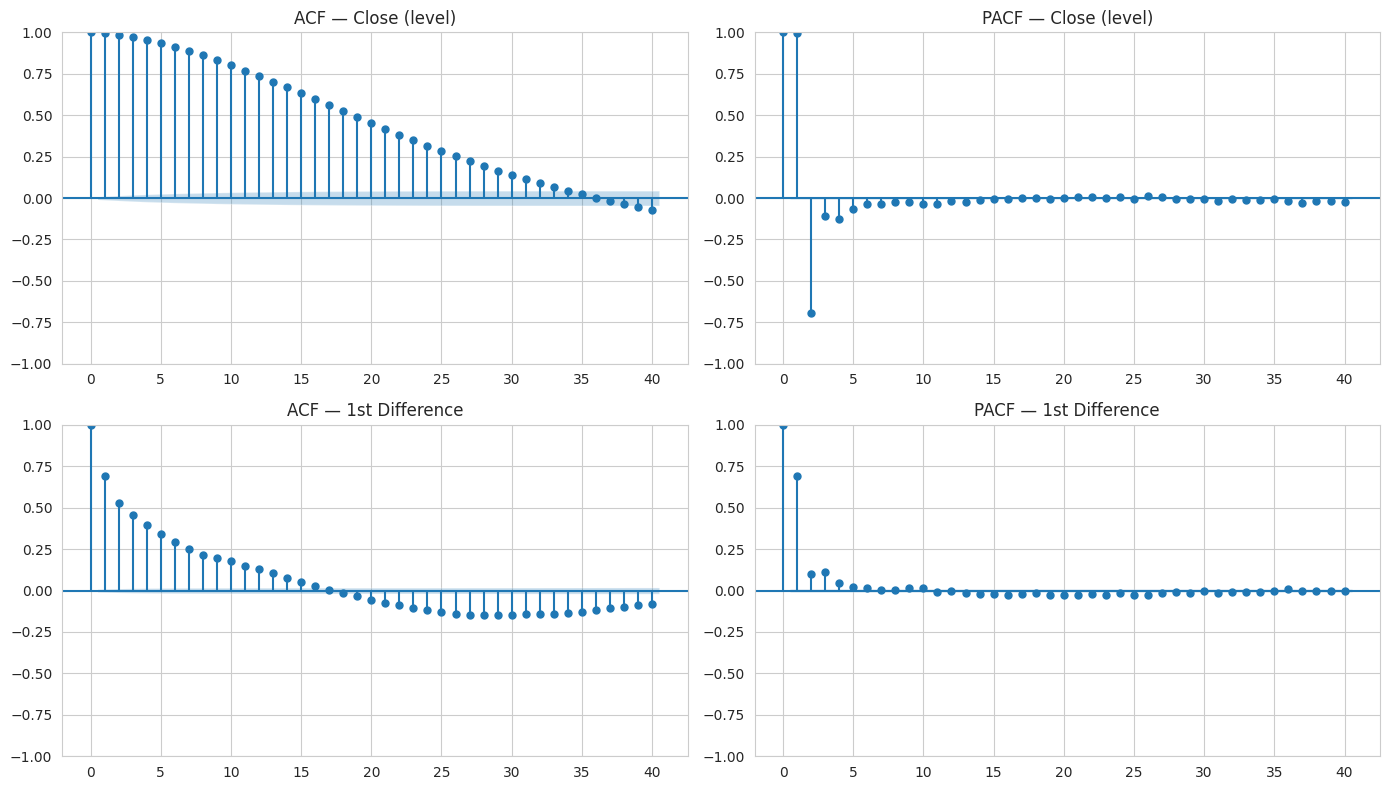

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df[TARGET], lags=40, ax=axes[0,0]); axes[0,0].set_title("ACF — Close (level)")
plot_pacf(df[TARGET], lags=40, ax=axes[0,1]); axes[0,1].set_title("PACF — Close (level)")
plot_acf(df[TARGET].diff().dropna(), lags=40, ax=axes[1,0]); axes[1,0].set_title("ACF — 1st Difference")
plot_pacf(df[TARGET].diff().dropna(), lags=40, ax=axes[1,1]); axes[1,1].set_title("PACF — 1st Difference")
plt.tight_layout()
plt.show()

## 5. Data Preprocessing (Step 3)

Pipeline (identical procedure required by the project spec):
1. **Missing values** → Forward Fill, then Interpolation for any remainder
2. **Train/Test split** → 80% / 20%, chronological, **no shuffling**
3. **Scaling** → MinMaxScaler, **fit on train only**
4. **Sliding window** → `w = 30`, used to build supervised samples for XGBoost/LSTM/Transformer
5. **Seed** → 42 everywhere randomness is involved


In [14]:
# 5.1 Missing values
df_clean = df.copy()
df_clean = df_clean.ffill()
df_clean = df_clean.interpolate(method="linear")
print("Remaining NaNs:", df_clean.isna().sum().sum())

Remaining NaNs: 0


In [15]:
# 5.2 Chronological 80/20 split (index-based, shared by ALL models)
N = len(df_clean)
split_idx = int(N * (1 - TEST_RATIO))
print(f"Total obs: {N} | Train: {split_idx} | Test: {N - split_idx}")

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]
print("Train range:", train_df.index.min(), "->", train_df.index.max())
print("Test range :", test_df.index.min(), "->", test_df.index.max())

Total obs: 52416 | Train: 41932 | Test: 10484
Train range: 2017-01-01 00:00:00 -> 2017-10-19 04:30:00
Test range : 2017-10-19 04:40:00 -> 2017-12-30 23:50:00


In [16]:
# 5.3 Scaling (fit on TRAIN ONLY to avoid leakage) - for ML/DL inputs
scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])

scaled_all = pd.DataFrame(
    scaler.transform(df_clean[FEATURES]),
    columns=FEATURES, index=df_clean.index
)
target_idx_in_features = FEATURES.index(TARGET)

In [17]:
# 5.4 Sliding window dataset builder (w = 30) for ML/DL models
def build_windows(scaled_df, window=WINDOW, target_col=TARGET, feature_cols=FEATURES):
    values = scaled_df[feature_cols].values
    target_pos = feature_cols.index(target_col)
    X, y, idx = [], [], []
    for t in range(window, len(values)):
        X.append(values[t-window:t, :])          # shape (window, n_features)
        y.append(values[t, target_pos])           # scaled target at time t
        idx.append(scaled_df.index[t])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)

X_all, y_all, idx_all = build_windows(scaled_all)
print("X_all shape:", X_all.shape, "| y_all shape:", y_all.shape)

# Align with the SAME chronological split_idx used above.
# Sample at original time index t belongs to test set if t >= split_idx.
window_split_idx = split_idx - WINDOW   # offset because first WINDOW points have no sample

X_train, y_train = X_all[:window_split_idx], y_all[:window_split_idx]
X_test,  y_test_scaled  = X_all[window_split_idx:], y_all[window_split_idx:]
idx_test = idx_all[window_split_idx:]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Test target timestamps:", idx_test.min(), "->", idx_test.max())
assert len(idx_test) == (N - split_idx), "Test alignment mismatch!"

X_all shape: (52386, 30, 5) | y_all shape: (52386,)
X_train: (41902, 30, 5) X_test: (10484, 30, 5)
Test target timestamps: 2017-10-19 04:40:00 -> 2017-12-30 23:50:00


In [18]:
# True (unscaled) test targets — the ground truth used for ALL models' evaluation
y_test_true = df_clean.loc[idx_test, TARGET].values
print(y_test_true[:5], "...", len(y_test_true), "points")

[25573.39168 25686.82713 26537.593   26928.3151  26758.16193] ... 10484 points


In [19]:
# Helper to inverse-transform a scaled Close prediction back to price units
def inverse_close(scaled_close_values):
    dummy = np.zeros((len(scaled_close_values), len(FEATURES)))
    dummy[:, target_idx_in_features] = scaled_close_values
    return scaler.inverse_transform(dummy)[:, target_idx_in_features]

## 6. Evaluation Metric Helper (MAE, RMSE, MAPE, R²)

In [28]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_name}] MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}% | R2={r2:.4f}")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

results = []          # summary metrics, one row per model
errors_by_model = {}  # per-timestamp absolute errors, for paired statistical tests
preds_by_model = {}   # store predictions for plotting

## 7. Model 1 — Holt-Winters Exponential Smoothing (Step 4)

Univariate. Fit on training `Close`, then produce a **walk-forward one-step-ahead**
forecast for every test timestamp (re-fit using true history up to `t-1`), so predictions
align exactly with `idx_test`.

> Walk-forward refitting can be slow on long series — for very large datasets, consider
> refitting every k steps instead of every single step (trade-off noted in the discussion).


In [29]:
# import time
# t0 = time.time()

# hw_preds = []
# history = list(train_df[TARGET].values)

# for t in range(len(idx_test)):
#     try:
#         model_hw = ExponentialSmoothing(
#             pd.Series(history), trend="add", seasonal=None, initialization_method="estimated"
#         ).fit()
#         pred = model_hw.forecast(1)[0]
#     except Exception:
#         pred = history[-1]  # fallback: naive persistence if model fails to converge
#     hw_preds.append(pred)
#     history.append(y_test_true[t])  # append TRUE value (walk-forward, leak-free for next step)

# hw_time = time.time() - t0
# hw_preds = np.array(hw_preds)
# print(f"Holt-Winters walk-forward training time: {hw_time:.2f}s")


In [30]:
import time
t0 = time.time()

# Fit once on the training data
model_hw = ExponentialSmoothing(
    train_df[TARGET], trend="add", seasonal=None, initialization_method="estimated"
).fit()

# Forecast the entire test set in one go
hw_preds = model_hw.forecast(len(idx_test)).values

hw_time = time.time() - t0
print(f"Holt-Winters block forecast time: {hw_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Holt-Winters block forecast time: 1.41s


In [31]:
res = evaluate(y_test_true, hw_preds, "Holt-Winters")
res["TrainTime_s"] = hw_time
results.append(res)
errors_by_model["Holt-Winters"] = np.abs(y_test_true - hw_preds)
preds_by_model["Holt-Winters"] = hw_preds

[Holt-Winters] MAE=711154.8309 | RMSE=822509.0248 | MAPE=2555.14% | R2=-17790.8173


## 8. Model 2 — ARIMA (Step 5)

Order `(p,d,q)` chosen via a small grid search on AIC over the training set
(default search space `p,q ∈ {0,1,2}`, `d=1` informed by the ADF test above).
Forecast uses the same walk-forward one-step-ahead procedure for fair comparison.

In [32]:
from itertools import product

def select_arima_order(train_series, p_range=range(0,3), d=1, q_range=range(0,3)):
    best_aic, best_order = np.inf, (1,1,1)
    for p, q in product(p_range, q_range):
        try:
            m = ARIMA(train_series, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d, q)
        except Exception:
            continue
    return best_order, best_aic

best_order, best_aic = select_arima_order(train_df[TARGET])
print("Selected ARIMA order:", best_order, "AIC:", round(best_aic, 2))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  

Selected ARIMA order: (1, 1, 2) AIC: 634351.01


In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

t0 = time.time()

model = SARIMAX(
    train_df[TARGET],
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

# CHANGED from 'results' to 'arima_model_res'
arima_model_res = model.fit(disp=False)

preds = []

for y in y_test_true:
    pred = arima_model_res.forecast(1).iloc[0]
    preds.append(pred)

    # Cập nhật mô hình, KHÔNG refit
    arima_model_res = arima_model_res.append([y], refit=False)

arima_preds = np.asarray(preds)

arima_time = time.time() - t0

print(f"ARIMA walk-forward time: {arima_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


ARIMA walk-forward time: 2395.05s


In [34]:
res = evaluate(y_test_true, arima_preds, "ARIMA")
res["TrainTime_s"] = arima_time
results.append(res)
errors_by_model["ARIMA"] = np.abs(y_test_true - arima_preds)
preds_by_model["ARIMA"] = arima_preds

[ARIMA] MAE=253.3620 | RMSE=387.8784 | MAPE=0.87% | R2=0.9960


## 9. Model 3 — XGBoost (Step 6)

Uses the windowed multivariate dataset (`X_train`, `X_test`, window=30, all 5 OHLCV features
flattened) built in the preprocessing step. `random_state=42`.


In [35]:
print(results)

[{'Model': 'Holt-Winters', 'MAE': 711154.83093462, 'RMSE': np.float64(822509.0247784831), 'MAPE': np.float64(2555.141421608093), 'R2': -17790.817321640076, 'TrainTime_s': 1.408691167831421}, {'Model': 'ARIMA', 'MAE': 253.36198063657034, 'RMSE': np.float64(387.87840180234423), 'MAPE': np.float64(0.8689844062251442), 'R2': 0.996043326975423, 'TrainTime_s': 2395.0492646694183}]


In [36]:
# Flatten window for XGBoost: (n_samples, window*n_features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED
)
xgb_model.fit(X_train_flat, y_train)
xgb_train_time = time.time() - t0

t0 = time.time()
xgb_pred_scaled = xgb_model.predict(X_test_flat)
xgb_infer_time = time.time() - t0

xgb_preds = inverse_close(xgb_pred_scaled)
print(f"XGBoost train time: {xgb_train_time:.2f}s | inference time: {xgb_infer_time:.4f}s")

XGBoost train time: 15.62s | inference time: 0.0862s


In [37]:
res = evaluate(y_test_true, xgb_preds, "XGBoost")
res["TrainTime_s"] = xgb_train_time
results.append(res)
errors_by_model["XGBoost"] = np.abs(y_test_true - xgb_preds)
preds_by_model["XGBoost"] = xgb_preds

[XGBoost] MAE=256.4914 | RMSE=377.7277 | MAPE=0.89% | R2=0.9962


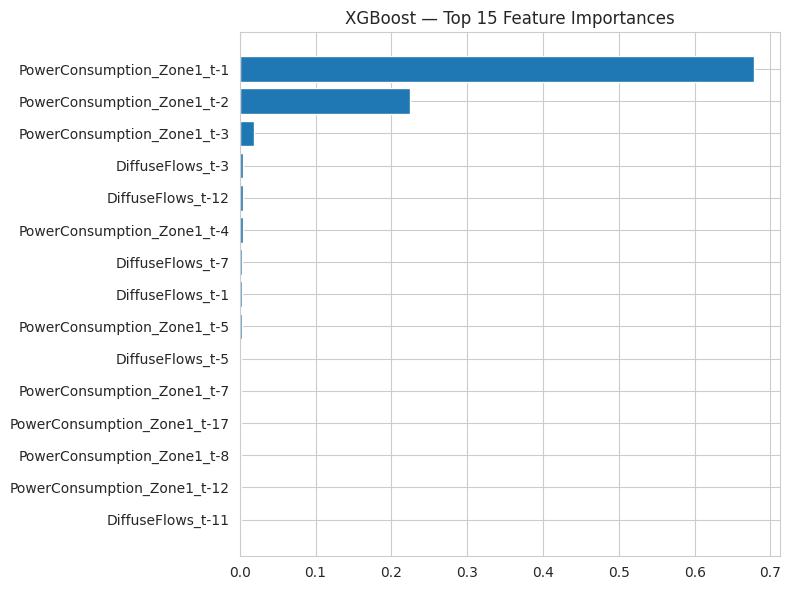

In [38]:
# Feature importance (top contributors across the flattened window)
importances = xgb_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]
feat_labels = [f"{FEATURES[i % len(FEATURES)]}_t-{WINDOW - i//len(FEATURES)}" for i in range(X_train_flat.shape[1])]
plt.figure(figsize=(8,6))
plt.barh(range(top_n), importances[top_idx])
plt.yticks(range(top_n), [feat_labels[i] for i in top_idx])
plt.title("XGBoost — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 10. Model 4 — LSTM (Step 7)

Sequential deep learning model using the same windowed input `X_train` (3D: samples, window, features).

In [39]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

n_features = X_train.shape[2]

lstm_model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=0
)
lstm_train_time = time.time() - t0
print(f"LSTM train time: {lstm_train_time:.2f}s | epochs run: {len(history_lstm.history['loss'])}")

LSTM train time: 125.77s | epochs run: 12


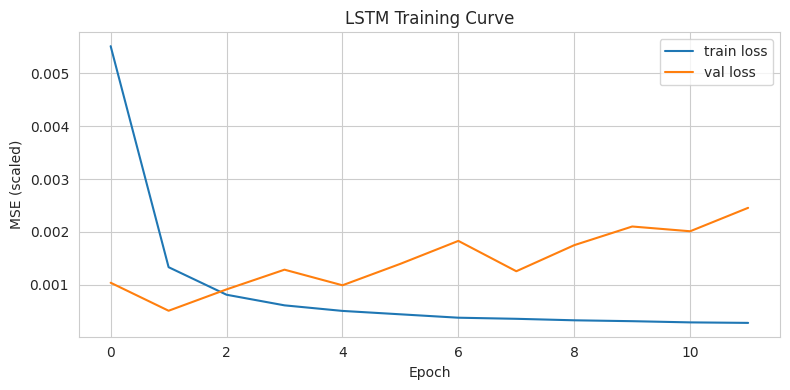

In [41]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()


In [42]:
t0 = time.time()
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
lstm_infer_time = time.time() - t0

lstm_preds = inverse_close(lstm_pred_scaled)
res = evaluate(y_test_true, lstm_preds, "LSTM")
res["TrainTime_s"] = lstm_train_time
results.append(res)
errors_by_model["LSTM"] = np.abs(y_test_true - lstm_preds)
preds_by_model["LSTM"] = lstm_preds
print(f"Inference time: {lstm_infer_time:.4f}s")

[LSTM] MAE=532.3718 | RMSE=770.3330 | MAPE=1.82% | R2=0.9844
Inference time: 1.3289s


## 11. Model 5 — Transformer (Step 8)

Lightweight Transformer encoder (multi-head self-attention + feed-forward block) for
sequence regression, using the same windowed input as LSTM/XGBoost.

In [43]:
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)
    res = x
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + res)
    return x

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

inputs = layers.Input(shape=(WINDOW, n_features))
x = transformer_encoder(inputs)
x = transformer_encoder(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)

transformer_model = models.Model(inputs, outputs)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 5)     │      5,893 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 5)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 5)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 5)     │         10 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │        768 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 5)     │        645 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 5)     │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 5)     │         10 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 5)     │      5,893 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 5)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 5)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 5)     │         10 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │        768 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 5)     │        645 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 5)     │          0 │ dense_3[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 5)     │         10 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,877 (58.11 KB)

 Trainable params: 14,877 (58.11 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop_tr = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_tr = transformer_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop_tr], verbose=0
)
tr_train_time = time.time() - t0
print(f"Transformer train time: {tr_train_time:.2f}s | epochs run: {len(history_tr.history['loss'])}")

Transformer train time: 241.78s | epochs run: 38


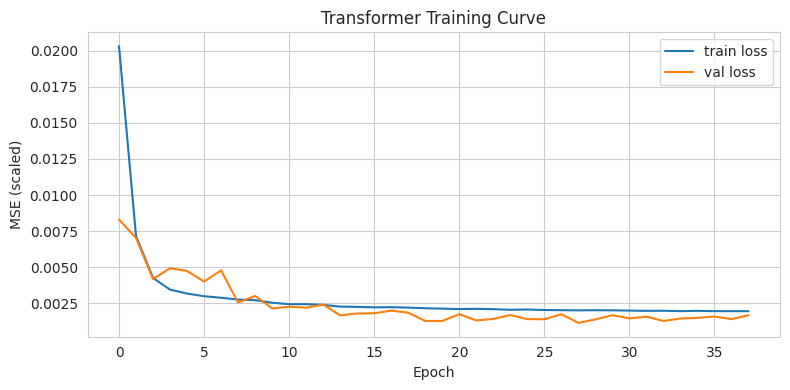

In [45]:
plt.figure(figsize=(8,4))
plt.plot(history_tr.history["loss"], label="train loss")
plt.plot(history_tr.history["val_loss"], label="val loss")
plt.title("Transformer Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()

In [46]:
t0 = time.time()
tr_pred_scaled = transformer_model.predict(X_test, verbose=0).flatten()
tr_infer_time = time.time() - t0

tr_preds = inverse_close(tr_pred_scaled)
res = evaluate(y_test_true, tr_preds, "Transformer")
res["TrainTime_s"] = tr_train_time
results.append(res)
errors_by_model["Transformer"] = np.abs(y_test_true - tr_preds)
preds_by_model["Transformer"] = tr_preds
print(f"Inference time: {tr_infer_time:.4f}s")

[Transformer] MAE=1066.2746 | RMSE=1394.0121 | MAPE=3.81% | R2=0.9489
Inference time: 3.2969s


## 12. Performance Comparison Table (Step 9 & 10)

In [47]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df[["MAE", "RMSE", "MAPE", "R2", "TrainTime_s"]]
results_df.sort_values("RMSE")


,MAE,RMSE,MAPE,R2,TrainTime_s
Model,,,,,
XGBoost,256.491387,377.727660,0.890094,0.996248,15.621284
ARIMA,253.361981,387.878402,0.868984,0.996043,2395.049265
LSTM,532.371759,770.333009,1.823165,0.984394,125.768634
Transformer,1066.274578,1394.012063,3.813068,0.948894,241.779749
Holt-Winters,711154.830935,822509.024778,2555.141422,-17790.817322,1.408691


In [48]:
results_df.to_csv("tcps_model_comparison_results.csv")
print("Saved: tcps_model_comparison_results.csv")

Saved: tcps_model_comparison_results.csv


## 13. Visualization of Results

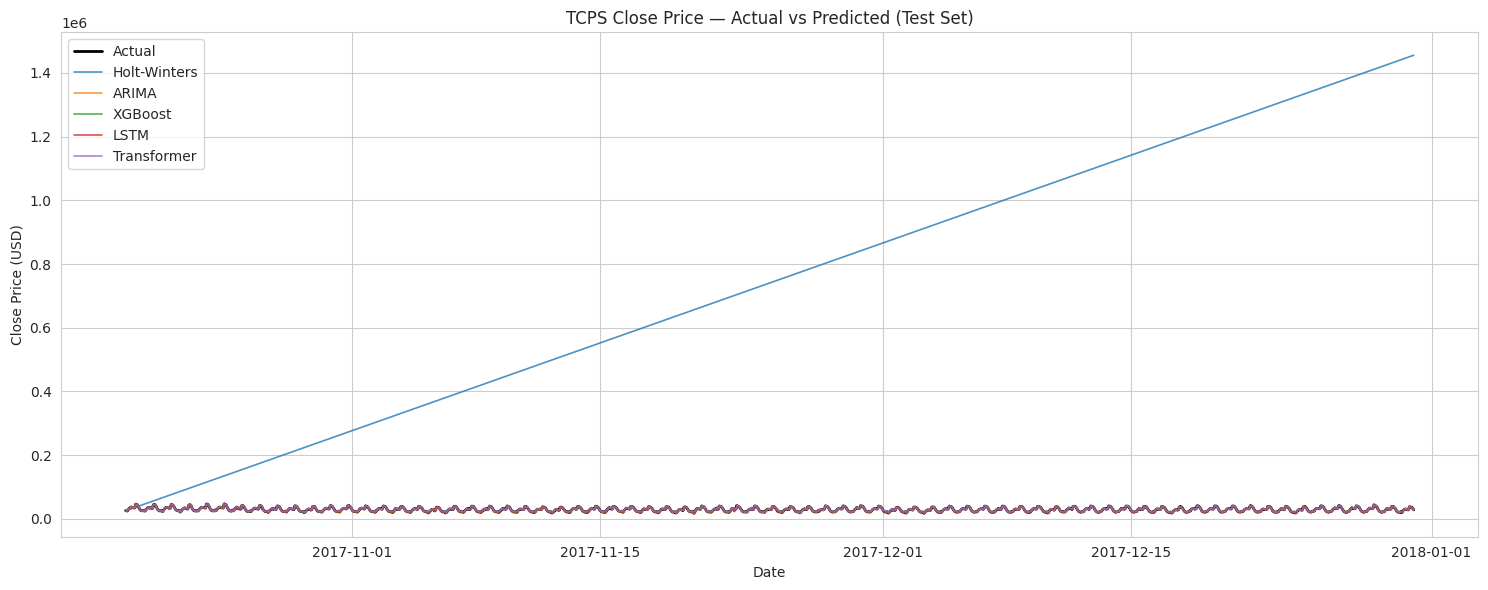

In [49]:
# 13.1 Predicted vs Actual — all models overlay
plt.figure(figsize=(15, 6))
plt.plot(idx_test, y_test_true, label="Actual", color="black", linewidth=2)
for name, preds in preds_by_model.items():
    plt.plot(idx_test, preds, label=name, alpha=0.8, linewidth=1.2)
plt.title("TCPS Close Price — Actual vs Predicted (Test Set)")
plt.xlabel("Date"); plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

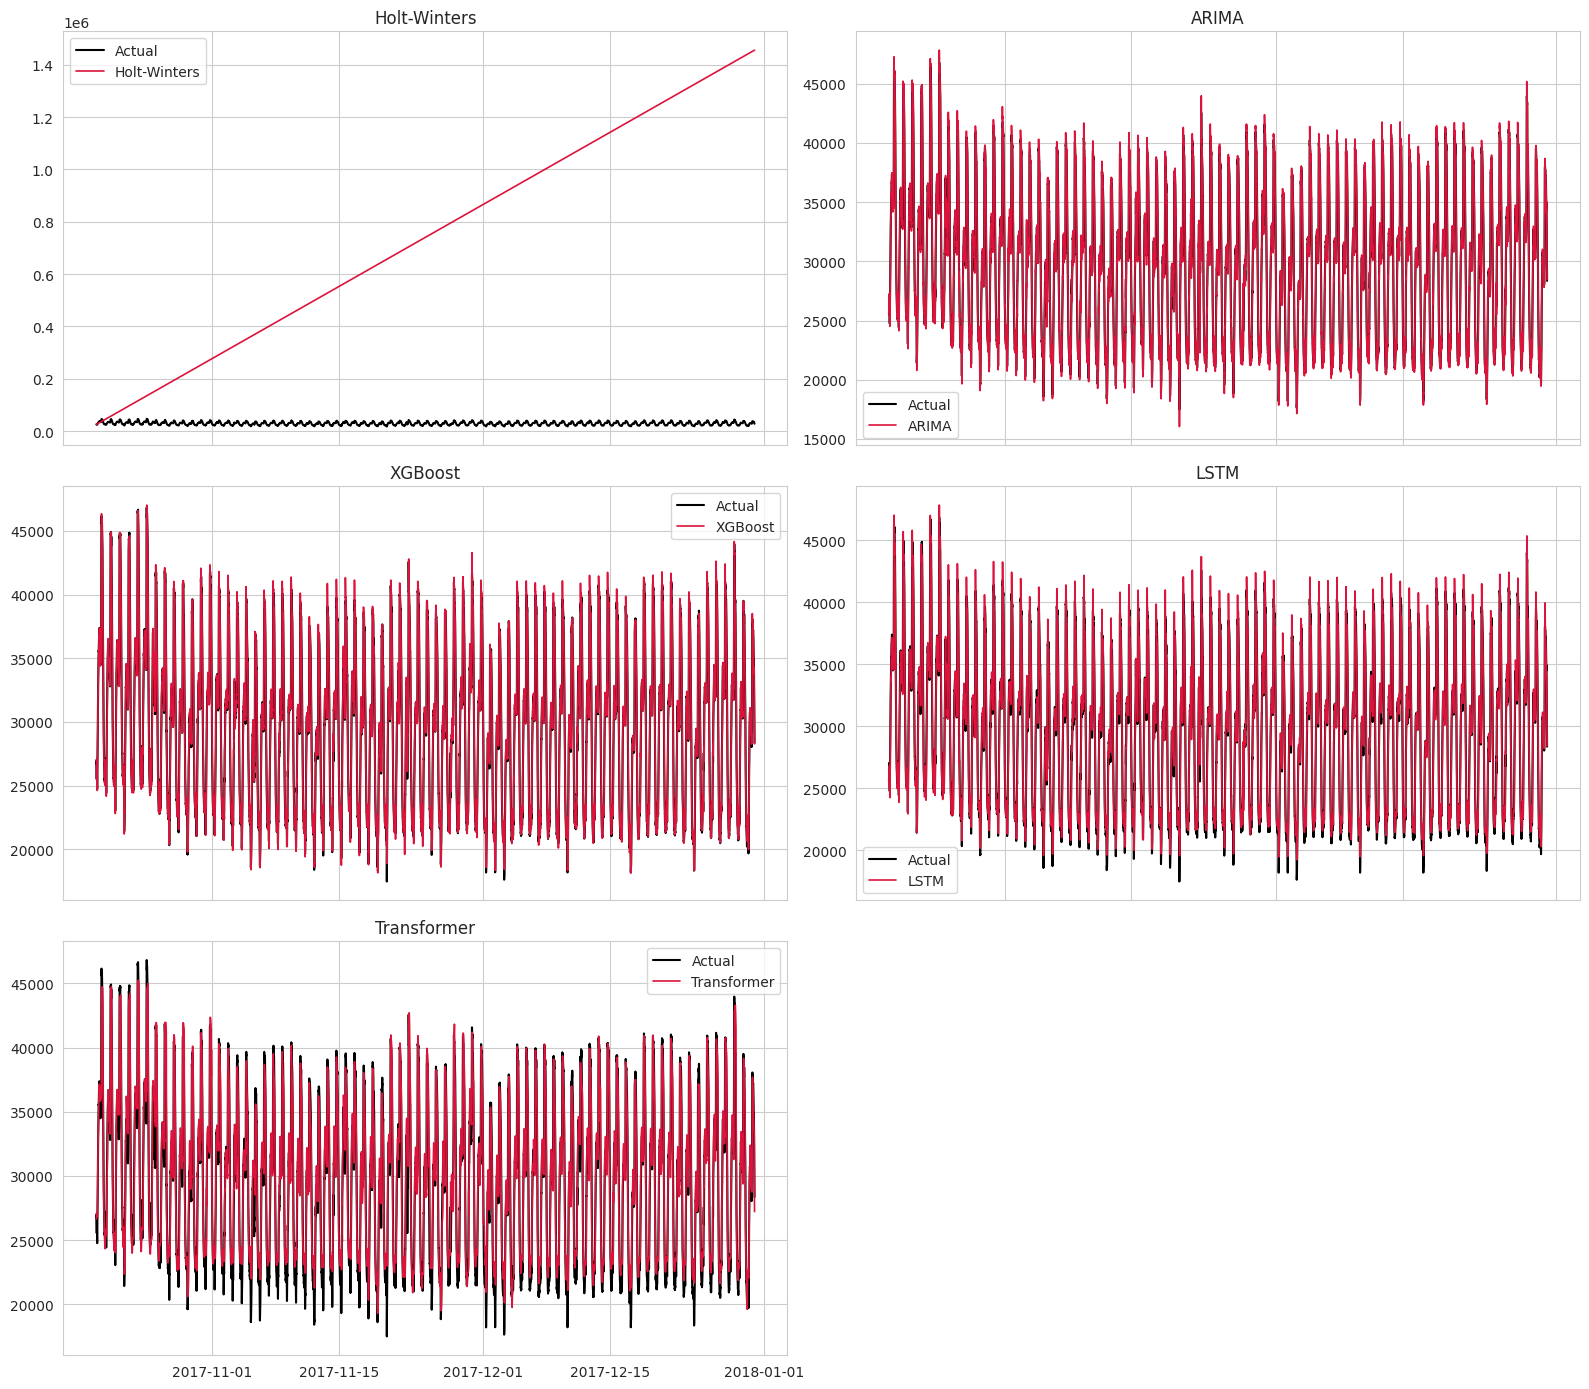

In [50]:
# 13.2 Individual subplots per model
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
for ax, (name, preds) in zip(axes.flatten(), preds_by_model.items()):
    ax.plot(idx_test, y_test_true, label="Actual", color="black", linewidth=1.5)
    ax.plot(idx_test, preds, label=name, color="crimson", linewidth=1.2)
    ax.set_title(name)
    ax.legend()
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

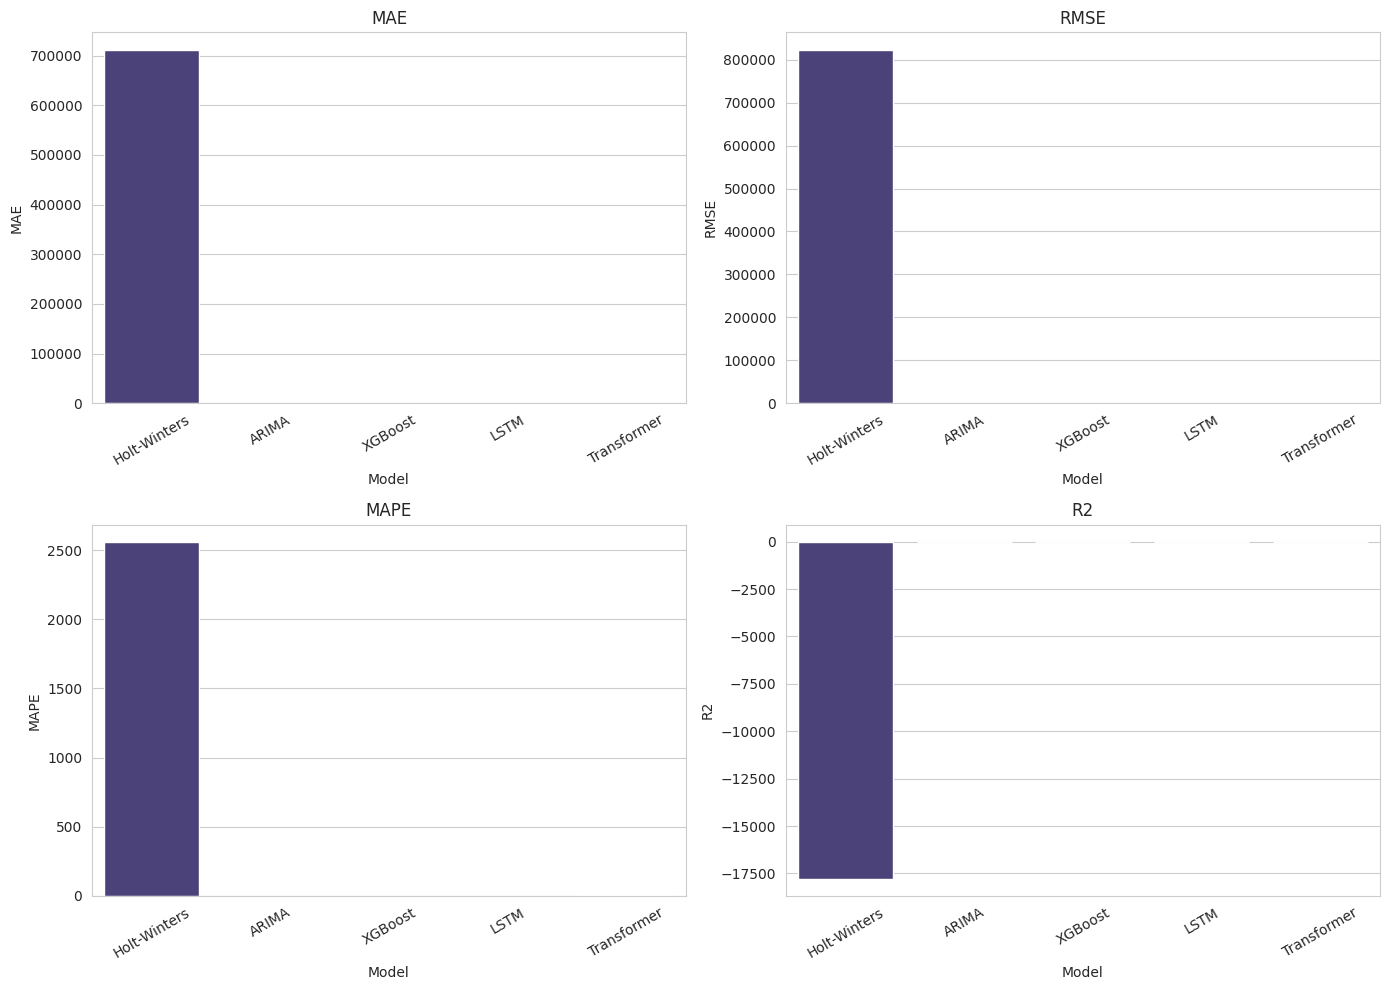

In [51]:
# 13.3 Metric comparison bar charts
metrics_to_plot = ["MAE", "RMSE", "MAPE", "R2"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    sns.barplot(x=results_df.index, y=results_df[metric], ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


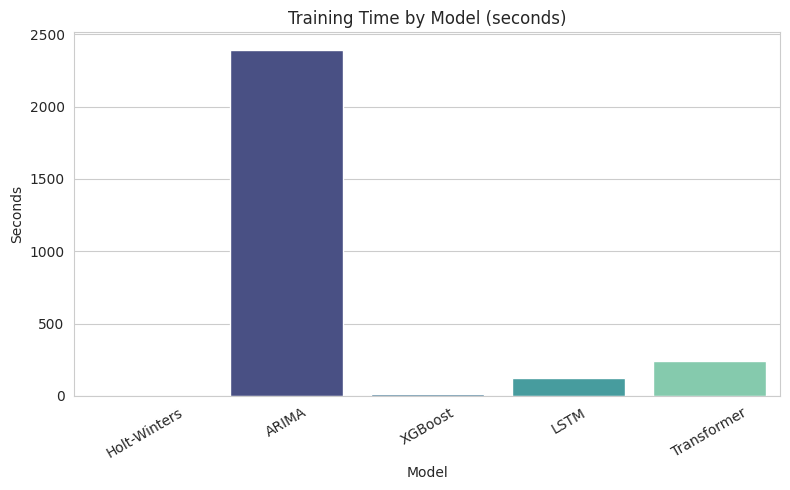

In [52]:
# 13.4 Training vs Inference time (computational cost)
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["TrainTime_s"], palette="mako")
plt.title("Training Time by Model (seconds)")
plt.ylabel("Seconds"); plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

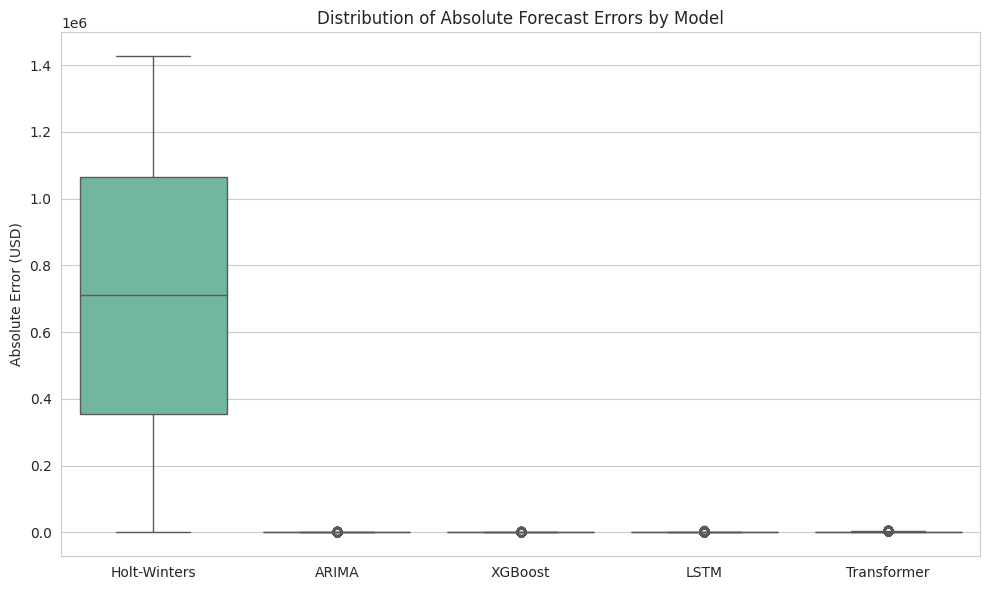

In [53]:
# 13.5 Error distribution boxplot (per-timestamp absolute errors)
err_df = pd.DataFrame(errors_by_model)
plt.figure(figsize=(10,6))
sns.boxplot(data=err_df, palette="Set2")
plt.title("Distribution of Absolute Forecast Errors by Model")
plt.ylabel("Absolute Error (USD)")
plt.tight_layout()
plt.show()

## 14. Statistical Comparison of Results (Step 12)

Because every model was evaluated on the **same aligned test timestamps**, the per-point
absolute errors are paired observations — enabling a valid **paired t-test** (or Wilcoxon
signed-rank test when normality is violated) between every pair of models.

**H₀:** No significant difference in forecast error between the two models
**H₁:** A significant difference exists

In [54]:
from itertools import combinations
from scipy.stats import wilcoxon, shapiro

model_names = list(errors_by_model.keys())
comparison_rows = []

for m1, m2 in combinations(model_names, 2):
    e1, e2 = errors_by_model[m1], errors_by_model[m2]
    diff = e1 - e2

    # Normality check on the differences (Shapiro-Wilk)
    try:
        _, p_norm = shapiro(diff)
    except Exception:
        p_norm = np.nan
    normal = p_norm > 0.05 if not np.isnan(p_norm) else False

    t_stat, p_t = stats.ttest_rel(e1, e2)
    try:
        w_stat, p_w = wilcoxon(e1, e2)
    except Exception:
        w_stat, p_w = np.nan, np.nan

    comparison_rows.append({
        "Model A": m1, "Model B": m2,
        "Shapiro p (normality of diff)": round(p_norm, 4) if not np.isnan(p_norm) else np.nan,
        "Paired t-test p-value": round(p_t, 4),
        "Significant (t-test, a=0.05)": p_t < 0.05,
        "Wilcoxon p-value": round(p_w, 4) if not np.isnan(p_w) else np.nan,
        "Significant (Wilcoxon, a=0.05)": (p_w < 0.05) if not np.isnan(p_w) else np.nan,
        "Recommended test": "t-test" if normal else "Wilcoxon"
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model A,Model B,Shapiro p (normality of diff),Paired t-test p-value,"Significant (t-test, a=0.05)",Wilcoxon p-value,"Significant (Wilcoxon, a=0.05)",Recommended test
0,Holt-Winters,ARIMA,0.0,0.0000,True,0.0,True,Wilcoxon
1,Holt-Winters,XGBoost,0.0,0.0000,True,0.0,True,Wilcoxon
2,Holt-Winters,LSTM,0.0,0.0000,True,0.0,True,Wilcoxon
3,Holt-Winters,Transformer,0.0,0.0000,True,0.0,True,Wilcoxon
4,ARIMA,XGBoost,0.0,0.1458,False,0.0,True,Wilcoxon
5,ARIMA,LSTM,0.0,0.0000,True,0.0,True,Wilcoxon
6,ARIMA,Transformer,0.0,0.0000,True,0.0,True,Wilcoxon
7,XGBoost,LSTM,0.0,0.0000,True,0.0,True,Wilcoxon
8,XGBoost,Transformer,0.0,0.0000,True,0.0,True,Wilcoxon
9,LSTM,Transformer,0.0,0.0000,True,0.0,True,Wilcoxon


In [56]:
comparison_df.to_csv("tcps_statistical_comparison.csv", index=False)
print("Saved: tcps_statistical_comparison.csv")

Saved: tcps_statistical_comparison.csv
